In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="PizzeriaDB",
    user="postgres",
    password="9446" 
)

items = pd.read_sql_query('SELECT * FROM items', conn)
orders = pd.read_sql_query('SELECT * FROM orders', conn)
orders["created_at"] = pd.to_datetime(orders["created_at"]).copy()

C:\Users\user\AppData\Local\Temp\ipykernel_13988\2388175923.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  items = pd.read_sql_query('SELECT * FROM items', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_13988\2388175923.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql_query('SELECT * FROM orders', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_13988\2388175923.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders["created_at"] = pd.to_datetime(orders["created_at"]).copy()


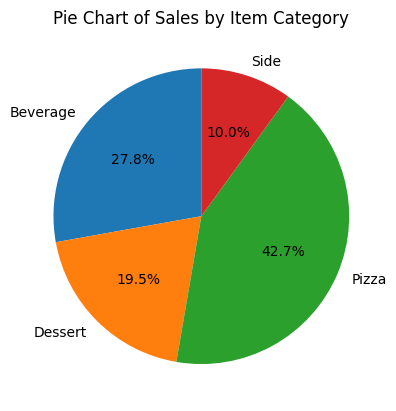

In [3]:
# Pie chart of Sales by Item Category
merged = orders.merge(items, on='item_id')
sizes = merged.groupby('item_category')['quantity'].sum()
labels = sizes.index
sizes = sizes.values

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart of Sales by Item Category")
plt.show()

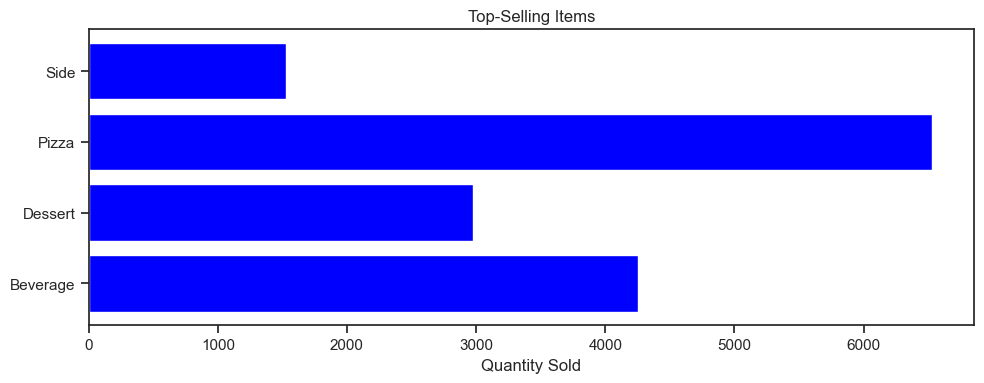

In [4]:
#Bar chart of Top-Selling Items
plt.figure(figsize=(10,4))
sns.set_theme(style="ticks")
items_sold=merged.groupby('item_category')['quantity']
plt.barh(items_sold.sum().index, items_sold.sum().values, color='blue')
plt.xlabel("Quantity Sold")
plt.ylabel("")
plt.title("Top-Selling Items")
plt.tight_layout()
plt.show()

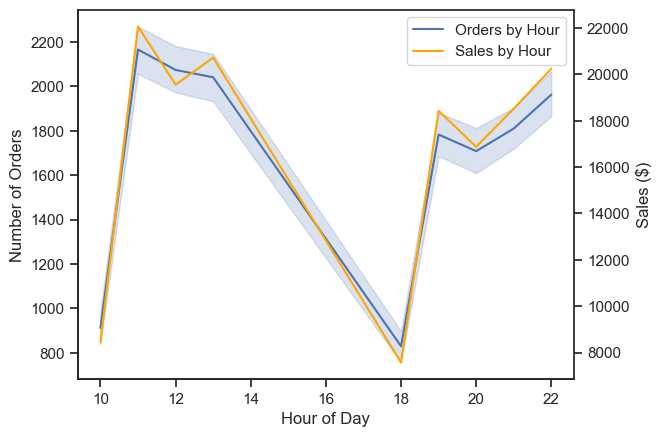

In [41]:
#Line chart of Orders by Hour and Sales by Hour 
orders["hour"] = orders["created_at"].dt.hour 
orders["sales"] = orders["quantity"] * merged['item_price'] 
sales_by_hour = orders.groupby('hour')['sales'].sum()
fig, ax1 = plt.subplots() 
sns.lineplot(data=orders, x='hour', y='quantity', estimator='sum', label='Orders by Hour') 
sns.set_theme(style="ticks") 
sns.despine() 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.xlabel("Hour of Day") 
plt.ylabel("Number of Orders") 
ax2 = ax1.twinx() 
ax2.plot(sales_by_hour.index, sales_by_hour.values, color= 'orange', label='Sales by Hour') 
ax2.set_ylabel("Sales ($)")
plt.show()

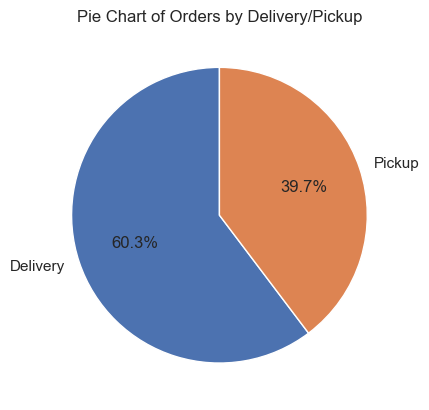

In [8]:
#Orders by delivery/pickup 
orders["delivery"] = orders["delivery"].replace({"0": "Pickup", "1": "Delivery"}) 
deliveries = orders["delivery"].value_counts() 
labels = deliveries.index 
sizes = deliveries.values 
fig1, ax1 = plt.subplots() 
ax1.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90) 
plt.title("Pie Chart of Orders by Delivery/Pickup") 
plt.show()